# Test Analysis

### TLDR
This notebook performs the final evaluation of the model using the test dataset.

### Objective
Evaluate the model's generalization capabilities on unseen data.

### Description
* **Data Loading**: Loads the test dataset and a trained checkpoint.
* **Metrics Calculation**: Calculates performance metrics: Confusion Matrix, Accuracy, Precision, Recall, and F1-score.
* **Error Analysis**: Visualizes the confusion matrix for class-wise error analysis.
* **Macro Comparison**: Displays macro metrics in a bar chart for quick comparison.

### Results
* **Confusion Matrix**: Visualization of the confusion matrix.
* **Performance Summary**: Bar chart summary of macro metrics.


In [1]:

# no teste vai ser diferente, vamos fazer tudo pelo tester, uma vez que o load_checkpoint não é necessário 
# todas as análises das metricas serão feitas pelo pandas
# e não será necessário variáveis globais
# e vai ter curva roc e auc


In [2]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Setting the custom classes
current_dir = os.getcwd() 
utils_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'utils'))
models_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'models'))
notebook_utils = os.path.abspath(os.path.join(current_dir, '..'))

if utils_path not in sys.path: sys.path.append(utils_path)
if models_path not in sys.path: sys.path.append(models_path)
if notebook_utils not in sys.path: sys.path.append(notebook_utils)

print(f"Adicionado ao PATH: {utils_path}")
print(f"Adicionado ao PATH: {models_path}")
print(f"Adicionado ao PATH: {notebook_utils}")

# Local/Project imports
import DatasetsDict as dd
import ModelTester as mt
from StaticMaskTraining import StaticMaskTraining
import NotebookUtils as nu

Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/utils
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/models
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/notebooks


/home/andre-marques/anaconda3/envs/PowerRanger-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#cuda 
torch.set_default_device('cuda')

In [4]:
# SETTING GLOBAL VARIABLES
var_root_dir = "../../checkpoints/"
var_global_checkpoint_masked = "galaxy10_resnet20_masked"
var_global_checkpoint_unmasked = "galaxy10_resnet20_unmasked"
var_global_epoch = 25

# Setting the class helper
utils = nu.NotebookUtils()
tester = mt.ModelTester("galaxy10", batch=16)

# 2. Executar o Teste
# Note: o seu ModelTester precisa retornar (cm, all_targets, all_probs)
# Se o seu atual só retorna a CM, ajuste o return dele!

m_cm, m_accuracy, m_precision, m_recall, m_f1, m_all_targets, m_all_probs, m_all_predictions = tester.test(
        var_global_checkpoint_masked, var_global_epoch
)

print(m_cm)

u_cm, u_accuracy, u_precision, u_recall, u_f1, u_all_targets, u_all_probs, u_all_predictions = tester.test(
        var_global_checkpoint_unmasked, var_global_epoch, use_mask = False
)

print(u_cm)

Loading train split from Hugging Face (checking download/cache)...
Galaxy10HFDataset: Loaded 15962 images for split 'train'.
Loading test split from Hugging Face (checking download/cache)...
Galaxy10HFDataset: Loaded 1774 images for split 'test'.
[[ 29   4  12  13   0   8   0  33   4   6]
 [  0 136  11   4   1   6   0  12   6   9]
 [  0   1 238   1   0   1   6   3   0   0]
 [  1   3   6 186   0   0   0   2   0   0]
 [  0   0   0   2  18   0   0   0   2   6]
 [  5   5   4   3   0 171   8  11   7   3]
 [  0   2  12   3   0   7 117  35   3   0]
 [ 19  13   1   5   1  21  32 169   9   3]
 [  0   1   0   0   0   0   1   0 139  16]
 [  0   3   0   1   0   1   0   0   9 164]]
[[ 24   2  15  19   0   4   3  33   6   3]
 [  2 118   9  19   0   5   0  21   3   8]
 [  0   3 234   9   0   0   2   2   0   0]
 [  0   3  14 180   0   0   0   0   1   0]
 [  0   0   2  13   9   0   1   0   2   1]
 [  7   1   7   9   0 160  10  16   5   2]
 [  0   2  18  12   0   4 117  25   1   0]
 [ 14   9   6  18   1

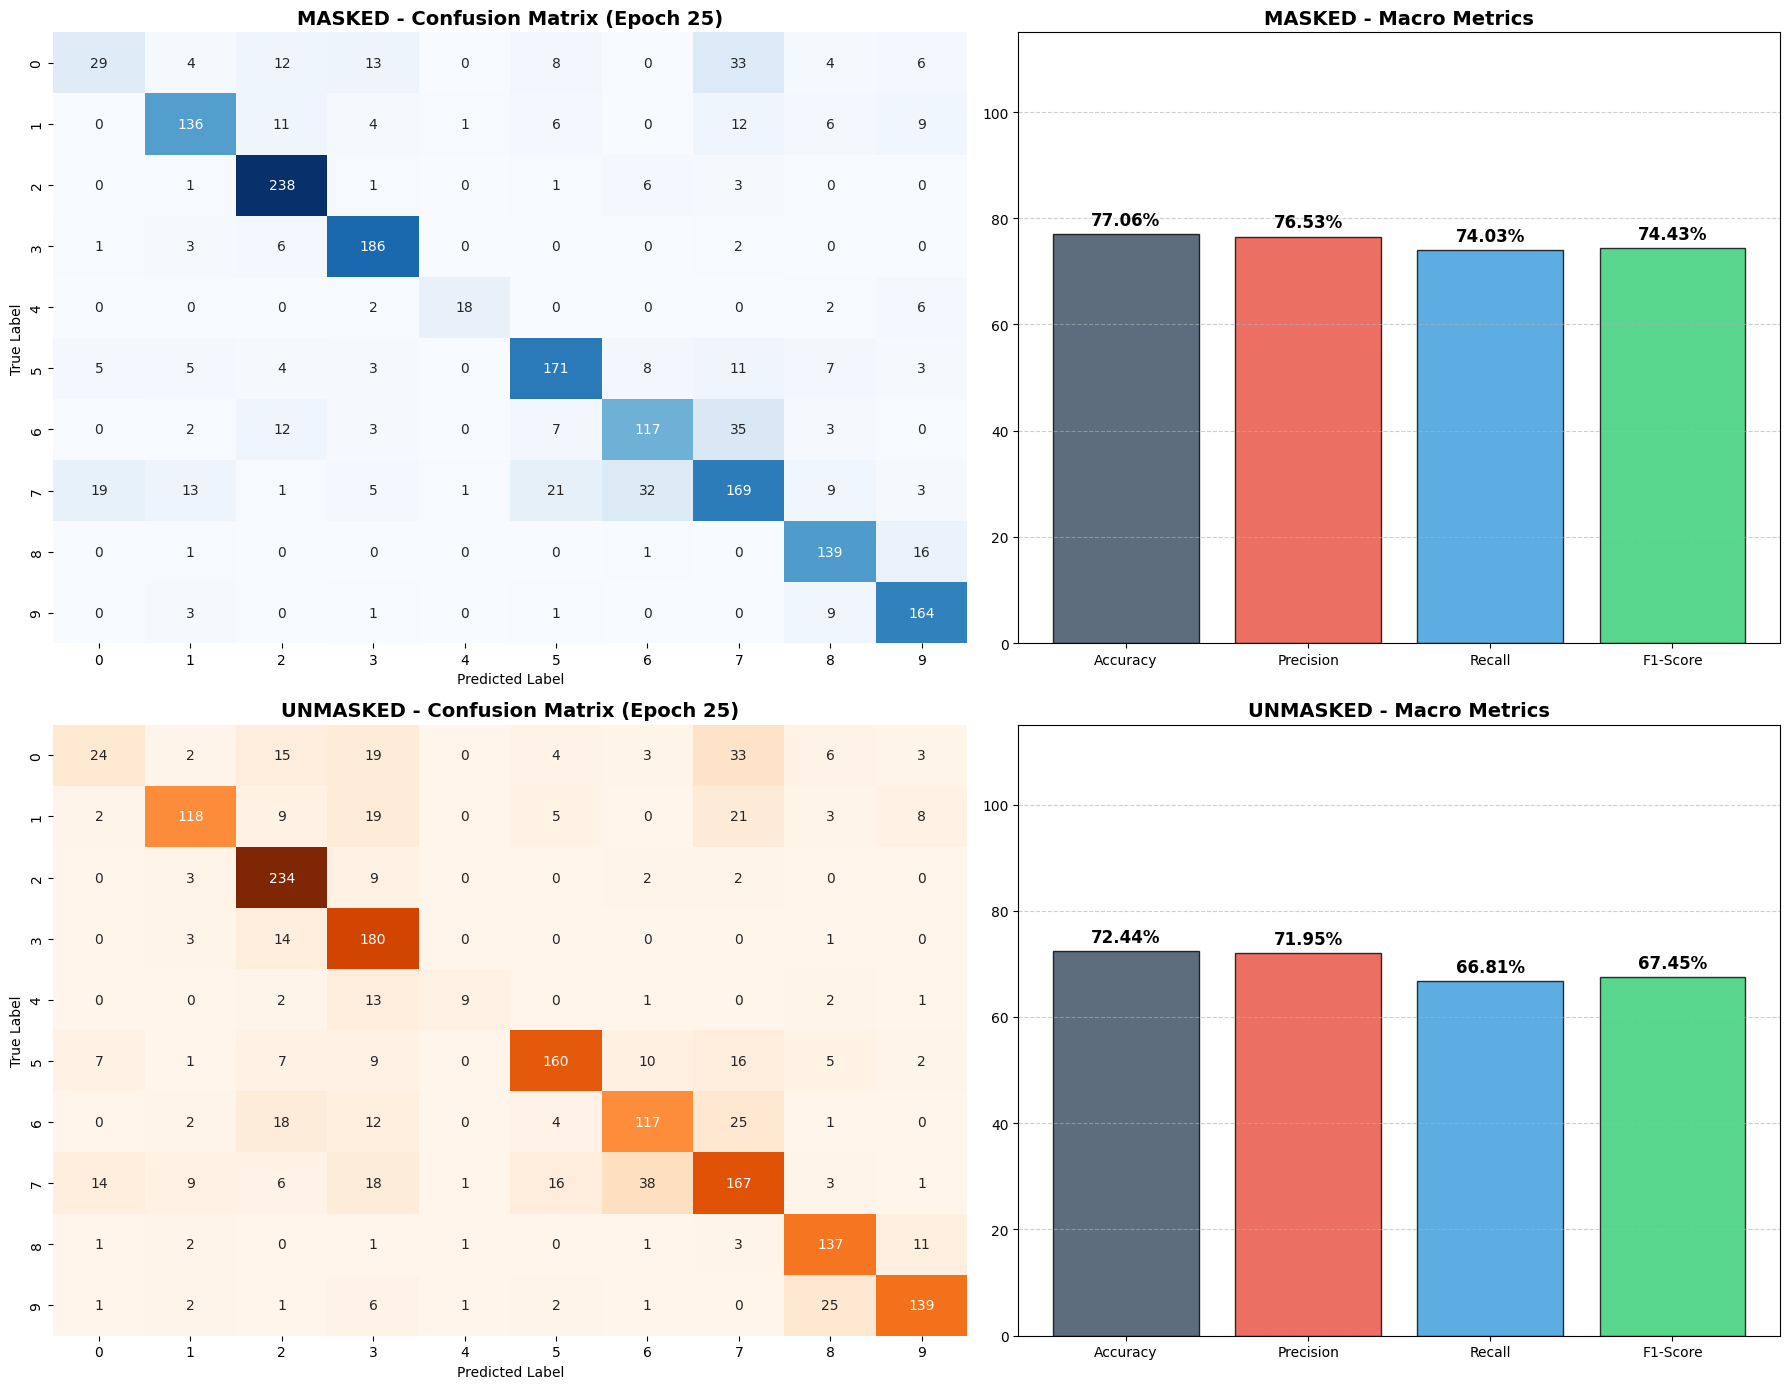

In [7]:
# --- CONFIGURAÇÃO DO PLOT (2 LINHAS, 2 COLUNAS) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14), gridspec_kw={'width_ratios': [1.2, 1]})

# Configurações de estilo comuns
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#34495e', '#e74c3c', '#3498db', '#2ecc71']

# --- LINHA 1: MASKED (CIMA) ---
# Matriz de Confusão Masked
sns.heatmap(m_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title(f'MASKED - Confusion Matrix (Epoch {var_global_epoch})', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# Gráfico de Barras Masked
m_metrics = [m_accuracy, m_precision, m_recall, m_f1]
m_bars = axes[0, 1].bar(metrics_names, m_metrics, color=colors, alpha=0.8, edgecolor='black')
axes[0, 1].set_ylim(0, 115)
axes[0, 1].set_title(f'MASKED - Macro Metrics', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.6)

for bar in m_bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}%', 
                    ha='center', va='bottom', fontweight='bold', fontsize=12)

# --- LINHA 2: UNMASKED (BAIXO) ---
# Matriz de Confusão Unmasked
sns.heatmap(u_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0], cbar=False) # Mudei para Oranges para diferenciar
axes[1, 0].set_title(f'UNMASKED - Confusion Matrix (Epoch {var_global_epoch})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Gráfico de Barras Unmasked
u_metrics = [u_accuracy, u_precision, u_recall, u_f1]
u_bars = axes[1, 1].bar(metrics_names, u_metrics, color=colors, alpha=0.8, edgecolor='black')
axes[1, 1].set_ylim(0, 115)
axes[1, 1].set_title(f'UNMASKED - Macro Metrics', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.6)

for bar in u_bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}%', 
                    ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_224692/1496069021.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


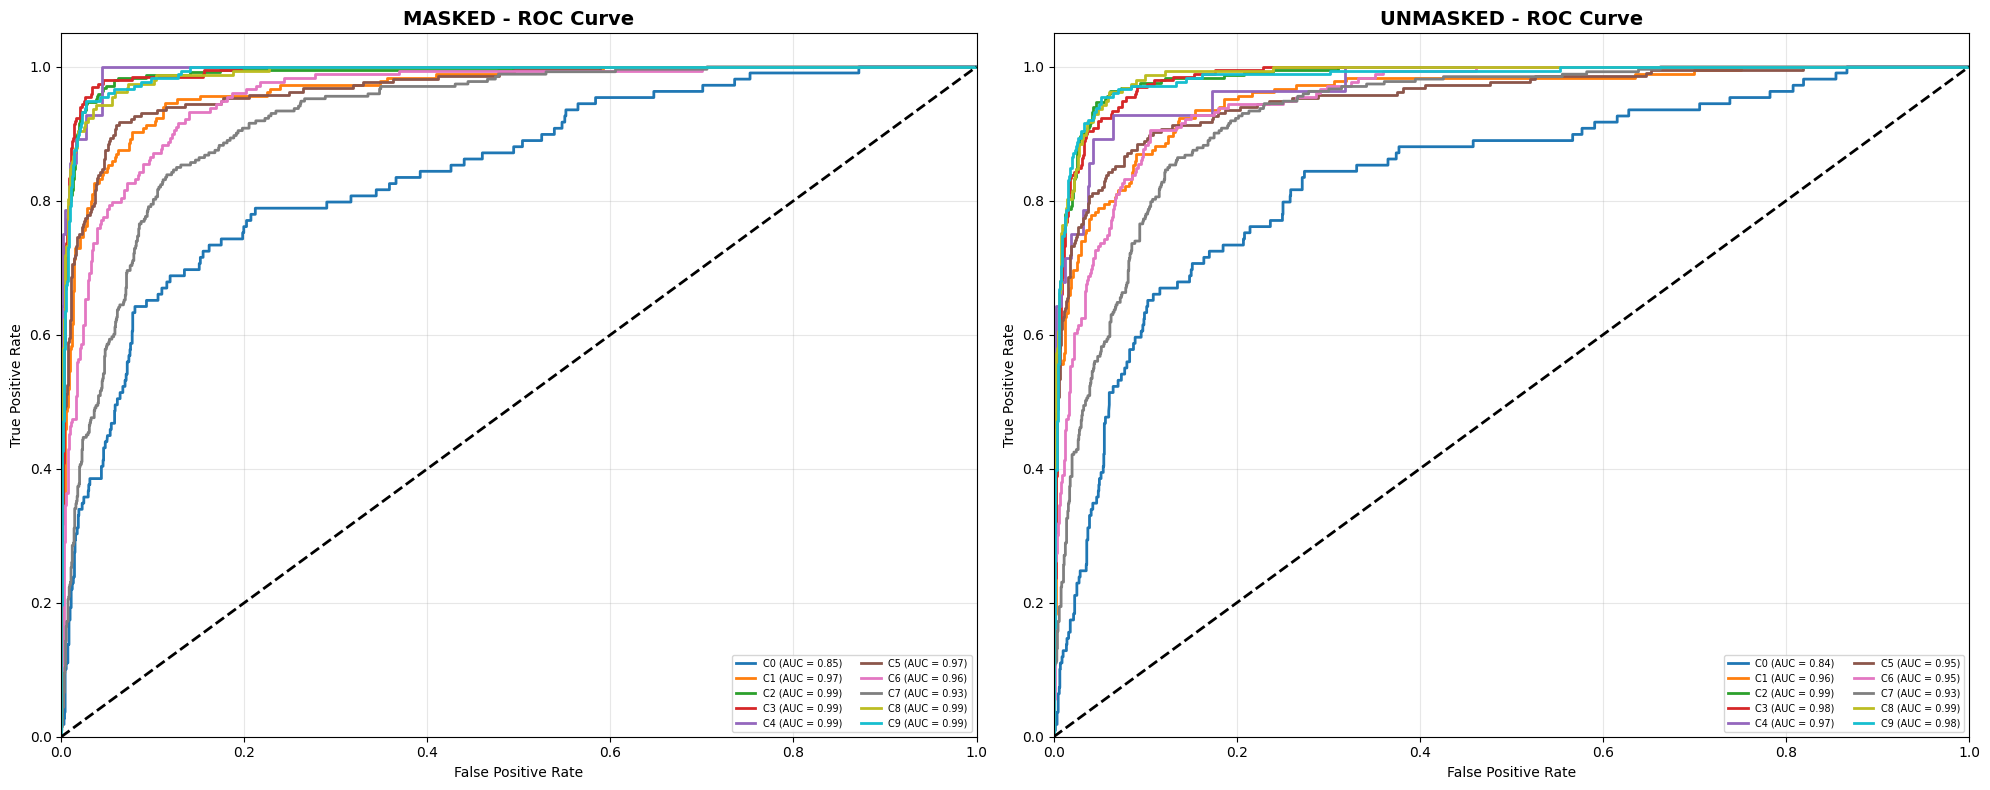

In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_comparative_roc(m_targets, m_probs, u_targets, u_probs, n_classes):
    """
    Plota as curvas ROC do modelo Masked e Unmasked lado a lado.
    """
    # Preparação dos dados para os dois modelos
    datasets = [
        {"targets": m_targets, "probs": np.array(m_probs), "title": "MASKED - ROC Curve"},
        {"targets": u_targets, "probs": np.array(u_probs), "title": "UNMASKED - ROC Curve"}
    ]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

    for idx, data in enumerate(datasets):
        ax = axes[idx]
        y_test = label_binarize(data["targets"], classes=np.arange(n_classes))
        y_score = data["probs"]
        
        # Calcular e plotar para cada classe
        for i, color in zip(range(n_classes), colors):
            fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2, 
                    label=f'C{i} (AUC = {roc_auc:.2f})')

        # Configurações do gráfico
        ax.plot([0, 1], [0, 1], 'k--', lw=2) # Linha de chute aleatório
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(data["title"], fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize='x-small', ncol=2)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- COMO EXECUTAR ---
# Usando as variáveis que você extraiu do tester.test() anteriormente:
plot_comparative_roc(
    m_all_targets, m_all_probs, 
    u_all_targets, u_all_probs, 
    n_classes=m_cm.shape[0]
)